### Evaluator-optimizer
In the evaluator-optimizer workflow, one LLM call generates a response while another provides evaluation and feedback in a loop.

When to use this workflow: This workflow is particularly effective when we have clear evaluation criteria, and when iterative refinement provides measurable value. The two signs of good fit are, first, that LLM responses can be demonstrably improved when a human articulates their feedback; and second, that the LLM can provide such feedback. This is analogous to the iterative writing process a human writer might go through when producing a polished document.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm

d:\OneDrive - Maarga Systems Private Limited\Documents\Agentic-AI-BridgeCourse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000001F4F7042300>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4F71A90A0>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict
# Graph state

class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [3]:
# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

In [4]:
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

In [5]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

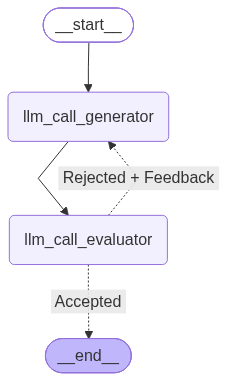

In [6]:
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()
# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [7]:
# Invoke
state = optimizer_workflow.invoke({"topic": "Agentic AI system"})
print(state["joke"])


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Topic:** Agentic AI system
   - **Format:** Joke
   - **Key Concepts:** Agentic AI refers to AI systems that can autonomously plan, execute tasks, make decisions, and interact with environments/tools to achieve goals. They're often described as "agents" that take initiative rather than just responding to prompts.

2.  **Identify Core Themes/Punchline Opportunities:**
   - Autonomy vs. human control
   - Over-competence or over-enthusiasm
   - Task delegation/multi-step planning
   - "Agent" vs. "Chatbot" distinction
   - Real-world analogies (managers, assistants, overachievers)
   - Tech humor tropes (bugs, loops, permissions, APIs)

3.  **Brainstorming Joke Structures:**
   - *Setup/Punchline format*
   - *Dialogue format*
   - *One-liner*
   - *Story-based*
   Let's aim for a classic setup/punchline with a tech/AI twist.

4.  **Drafting - Option 1:**
   Why did the agentic AI get promoted to manager?
   Because 